In [9]:
import duckdb 

In [10]:
con = duckdb.connect('../data/database/ne_pipeline.db')


In [11]:
con.execute("""
            SHOW TABLES
""").fetchall()


[('merged_view',),
 ('station_address',),
 ('stations_coordinates',),
 ('train_delay',),
 ('train_route',),
 ('weather',)]

In [12]:
train = con.sql("""
        SELECT * FROM train_delay
""")
weather = con.sql("""
        SELECT * FROM weather
""")

merged = con.sql("SELECT * FROM merged_view")
# merged.df().info()
train.df().info()

<class 'pandas.DataFrame'>
RangeIndex: 120801 entries, 0 to 120800
Data columns (total 4 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   train_no       120801 non-null  str           
 1   date           120801 non-null  datetime64[us]
 2   station_code   120801 non-null  str           
 3   delay_minutes  108797 non-null  Int32         
dtypes: Int32(1), datetime64[us](1), str(2)
memory usage: 4.3 MB


In [13]:
#missing if any in weather
train_weather_left_anti_join = con.sql("""
        SELECT td.*
        FROM train_delay td
        LEFT JOIN weather w
        ON td.station_code = w.station_code
        AND td.date = w.date
        WHERE w.station_code IS NULL""").to_df()
train_weather_left_anti_join.value_counts()

Series([], Name: count, dtype: int64)

In [14]:
train.to_df().info()

<class 'pandas.DataFrame'>
RangeIndex: 120801 entries, 0 to 120800
Data columns (total 4 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   train_no       120801 non-null  str           
 1   date           120801 non-null  datetime64[us]
 2   station_code   120801 non-null  str           
 3   delay_minutes  108797 non-null  Int32         
dtypes: Int32(1), datetime64[us](1), str(2)
memory usage: 4.3 MB


In [15]:
'''[ASSERT] Every date in train data exists in weather data, and vice versa'''

def assert_dates(df_ts,df_w):
    ts_pairs = set(zip(df_ts['station_code'], df_ts['date'].dt.date))
    w_pairs  = set(zip(df_w['station_code'], df_w['date'].dt.date))
    missing  = ts_pairs - w_pairs
    #set difference

    assert not missing,\
    f"Missing station-date pairs in weather: {missing}"
    
    
assert_dates(train.to_df(),weather.to_df())

In [16]:
''' 
Descriptive — which trains/routes/stations are worst overall
Temporal — day of week, month, season patterns
Weather correlation — rain/fog vs delay magnitude
Combined — a simple regression or feature importance showing which factor matters most
'''

' \nDescriptive — which trains/routes/stations are worst overall\nTemporal — day of week, month, season patterns\nWeather correlation — rain/fog vs delay magnitude\nCombined — a simple regression or feature importance showing which factor matters most\n'

In [17]:
merged.to_df().info()

<class 'pandas.DataFrame'>
RangeIndex: 120801 entries, 0 to 120800
Data columns (total 18 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   train_no                   120801 non-null  str           
 1   date                       120801 non-null  datetime64[us]
 2   station_code               120801 non-null  str           
 3   delay_minutes              108797 non-null  Int32         
 4   latitude                   120801 non-null  float64       
 5   longitude                  120801 non-null  float64       
 6   state                      118246 non-null  str           
 7   district                   118246 non-null  str           
 8   country                    120801 non-null  str           
 9   temperature_2m_max         120801 non-null  float64       
 10  temperature_2m_min         120801 non-null  float64       
 11  temperature_2m_mean        120801 non-null  float64       
 12 

In [18]:
con.sql("""
	select
    train_no, 
    min(date) as min_date,
    max(date) as max_date
    from merged_view
    group by train_no
    """).show()

┌──────────┬────────────┬────────────┐
│ train_no │  min_date  │  max_date  │
│ varchar  │    date    │    date    │
├──────────┼────────────┼────────────┤
│ 12346    │ 2025-05-11 │ 2026-05-10 │
│ 12505    │ 2025-05-11 │ 2026-05-10 │
│ 15909    │ 2025-05-11 │ 2026-05-10 │
│ 15960    │ 2025-05-12 │ 2026-05-09 │
│ 12067    │ 2025-05-12 │ 2026-05-09 │
│ 12423    │ 2025-05-11 │ 2026-05-10 │
│ 15615    │ 2025-05-11 │ 2026-05-10 │
│ 15946    │ 2025-05-11 │ 2026-05-10 │
│ 15657    │ 2025-05-11 │ 2026-05-10 │
└──────────┴────────────┴────────────┘



In [22]:
con.sql("""SELECT
    td.station_code,
    MIN(td.date) AS first_missing,
    MAX(td.date) AS last_missing,
    COUNT(*) AS missing_rows
FROM train_delay td
LEFT JOIN weather w
ON td.station_code = w.station_code
AND td.date = w.date
WHERE w.station_code IS NULL
GROUP BY td.station_code
ORDER BY missing_rows DESC""").show()

┌──────────────┬───────────────┬──────────────┬──────────────┐
│ station_code │ first_missing │ last_missing │ missing_rows │
│   varchar    │     date      │     date     │    int64     │
└──────────────┴───────────────┴──────────────┴──────────────┘
                            0 rows                          



In [23]:
'''  which trains/stations are worst overall '''
con.sql("""
	select 
        train_no,
        ROUND(avg(delay_minutes),2) as avg_delay,
        ROUND(median(delay_minutes),2) as median_delay,
        MIN(delay_minutes) as min_delay,
        MAX(delay_minutes) as max_delay,
        COUNT(*) - COUNT(delay_minutes) as missing_data
    from merged_view
    group by train_no
    order by avg_delay desc
""")


┌──────────┬───────────┬──────────────┬───────────┬───────────┬──────────────┐
│ train_no │ avg_delay │ median_delay │ min_delay │ max_delay │ missing_data │
│ varchar  │  double   │    double    │   int32   │   int32   │    int64     │
├──────────┼───────────┼──────────────┼───────────┼───────────┼──────────────┤
│ 15657    │      77.8 │         24.0 │       -53 │       744 │         1205 │
│ 15909    │     77.57 │         45.0 │       -42 │       970 │         4257 │
│ 15615    │     65.35 │         55.0 │       -61 │      2949 │         1462 │
│ 15946    │     41.33 │         24.0 │       -34 │       703 │          180 │
│ 12505    │     39.13 │         24.0 │       -11 │       732 │         2021 │
│ 15960    │     38.24 │         19.0 │       -47 │       963 │         1033 │
│ 12423    │     32.01 │         15.0 │       -24 │       696 │          731 │
│ 12346    │     29.62 │         13.0 │       -45 │       503 │          592 │
│ 12067    │      9.59 │          8.0 │       -26 │ 

In [24]:
con.sql("""SELECT 
    station_code,
    ROUND(AVG(delay_minutes), 2) AS avg_delay,
    ROUND(MEDIAN(delay_minutes), 2) AS median_delay,
    COUNT(DISTINCT train_no) AS trains_through_station
FROM merged_view
GROUP BY station_code
HAVING trains_through_station>1
ORDER BY avg_delay DESC"""
)

┌──────────────┬───────────┬──────────────┬────────────────────────┐
│ station_code │ avg_delay │ median_delay │ trains_through_station │
│   varchar    │  double   │    double    │         int64          │
├──────────────┼───────────┼──────────────┼────────────────────────┤
│ MKA          │     97.79 │         59.0 │                      2 │
│ BJF          │     79.74 │         34.0 │                      3 │
│ SBE          │     78.76 │         35.0 │                      2 │
│ FKM          │     77.76 │         30.0 │                      2 │
│ PNC          │     75.59 │         42.0 │                      2 │
│ GOGH         │     74.89 │         33.0 │                      3 │
│ SM           │     71.28 │         26.0 │                      2 │
│ BNGN         │     69.93 │         27.0 │                      2 │
│ PNBE         │     66.79 │         28.0 │                      2 │
│ MZP          │     66.13 │         32.5 │                      2 │
│  ·           │       ·   │      

In [25]:
'''Temporal — day of week, month, season patterns'''
'''1 Which day has the highest average delay'''
con.sql("""
	SELECT 
        DAYNAME(date) as day,
        ROUND(AVG(delay_minutes), 2) AS avg_delay,
    	ROUND(MEDIAN(delay_minutes), 2) AS median_delay,
        COUNT(*) as total_running_trains
    FROM merged_view
    GROUP BY  DAYNAME(date)
    ORDER BY avg_delay DESC
""")

┌───────────┬───────────┬──────────────┬──────────────────────┐
│    day    │ avg_delay │ median_delay │ total_running_trains │
│  varchar  │  double   │    double    │        int64         │
├───────────┼───────────┼──────────────┼──────────────────────┤
│ Friday    │     66.91 │         28.0 │                17368 │
│ Thursday  │     62.36 │         30.0 │                14196 │
│ Tuesday   │     58.68 │         31.0 │                17368 │
│ Sunday    │     57.02 │         31.0 │                16801 │
│ Monday    │     53.97 │         26.0 │                17368 │
│ Wednesday │     53.45 │         26.0 │                20332 │
│ Saturday  │     45.76 │         22.0 │                17368 │
└───────────┴───────────┴──────────────┴──────────────────────┘

In [26]:
'''2 Which month has the highest average delay'''
con.sql("""
	SELECT 
        MONTHNAME(date) as day,
        ROUND(AVG(delay_minutes), 2) AS avg_delay,
    	ROUND(MEDIAN(delay_minutes), 2) AS median_delay,
         COUNT(*) as total_running_trains
    FROM merged_view
    GROUP BY  MONTHNAME(date)
    ORDER BY avg_delay DESC
""")

┌───────────┬───────────┬──────────────┬──────────────────────┐
│    day    │ avg_delay │ median_delay │ total_running_trains │
│  varchar  │  double   │    double    │        int64         │
├───────────┼───────────┼──────────────┼──────────────────────┤
│ December  │    111.73 │         49.0 │                10327 │
│ January   │     92.43 │         50.0 │                10209 │
│ October   │     61.34 │         29.0 │                10266 │
│ November  │     58.75 │         29.0 │                 9919 │
│ April     │     55.12 │         35.0 │                 9932 │
│ February  │     52.63 │         31.0 │                 9268 │
│ March     │     48.98 │         28.0 │                10253 │
│ September │     45.87 │         22.0 │                 9936 │
│ May       │     43.97 │         23.0 │                10253 │
│ July      │     42.74 │         18.0 │                10266 │
│ June      │     39.02 │         17.0 │                 9919 │
│ August    │     31.72 │         16.0 │

In [27]:
con.sql("""SELECT 
    CASE 
        WHEN MONTH(date) IN (12,1,2) THEN 'Winter'
        WHEN MONTH(date) IN (3,4,5)  THEN 'Pre-Monsoon'
        WHEN MONTH(date) IN (6,7,8,9) THEN 'Monsoon'
        WHEN MONTH(date) IN (10,11)  THEN 'Post-Monsoon'
    END as season,
    ROUND(AVG(delay_minutes),2) as avg_delay,
    COUNT(*) as total_runs
FROM merged_view
GROUP BY season
ORDER BY avg_delay DESC""")

┌──────────────┬───────────┬────────────┐
│    season    │ avg_delay │ total_runs │
│   varchar    │  double   │   int64    │
├──────────────┼───────────┼────────────┤
│ Winter       │     86.73 │      29804 │
│ Post-Monsoon │     60.06 │      20185 │
│ Pre-Monsoon  │     49.43 │      30438 │
│ Monsoon      │     39.83 │      40374 │
└──────────────┴───────────┴────────────┘

In [28]:
con.sql("""SELECT
    CASE
        WHEN rain_sum = 0 THEN '0 mm'
        WHEN rain_sum <= 20 THEN '1-20 mm'
        WHEN rain_sum <= 50 THEN '21-50 mm'
        WHEN rain_sum <= 80 THEN '51-80 mm'
        ELSE '80+ mm'
    END AS rain_category,
    COUNT(*) AS total_records,
    ROUND(AVG(delay_minutes), 2) AS avg_delay,
    ROUND(MAX(delay_minutes), 2) AS max_delay,
FROM merged_view
GROUP BY rain_category""").show()

┌───────────────┬───────────────┬───────────┬───────────┐
│ rain_category │ total_records │ avg_delay │ max_delay │
│    varchar    │     int64     │  double   │   int32   │
├───────────────┼───────────────┼───────────┼───────────┤
│ 0 mm          │         54513 │     73.57 │       963 │
│ 51-80 mm      │          1191 │     39.95 │       457 │
│ 1-20 mm       │         55290 │     44.18 │      2949 │
│ 21-50 mm      │          9474 │     35.67 │       747 │
│ 80+ mm        │           333 │      74.9 │       465 │
└───────────────┴───────────────┴───────────┴───────────┘



<Axes: >

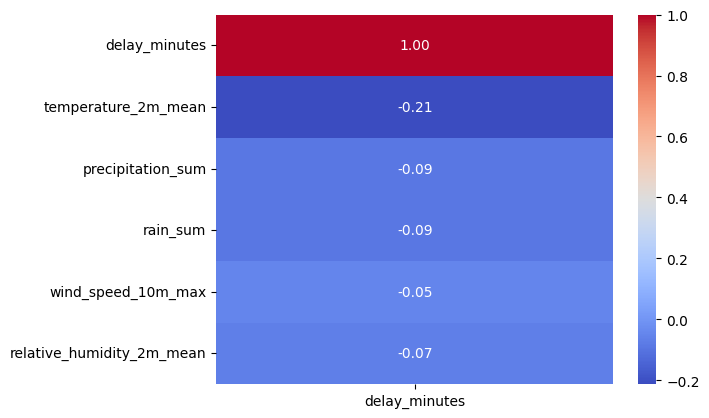

In [ ]:
import seaborn as sns

corr = merged.to_df()[['delay_minutes','temperature_2m_mean','precipitation_sum',
           'rain_sum','wind_speed_10m_max','wind_gusts_10m_max','relative_humidity_2m_mean']].corr()[['delay_minutes']]

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')

In [30]:
'''Contrary to the initial hypothesis that monsoon rainfall drives train delays in Northeast India, 
temperature is the strongest weather predictor (r = -0.23). Delays peak in winter (Dec-Jan avg 100+ min) 
and are lowest during monsoon (Aug avg 31 min), 
suggesting dense fog on Indo-Gangetic plain routes is the primary weather mechanism, not rain'''

'Contrary to the initial hypothesis that monsoon rainfall drives train delays in Northeast India, \ntemperature is the strongest weather predictor (r = -0.23). Delays peak in winter (Dec-Jan avg 100+ min) \nand are lowest during monsoon (Aug avg 31 min), \nsuggesting dense fog on Indo-Gangetic plain routes is the primary weather mechanism, not rain'

In [31]:
df = merged.to_df()
#will need hourly update to get fog codes
df['is_fog'] = df['weather_code'].isin([45, 48])
df.groupby('is_fog')['delay_minutes'].mean()

is_fog
False    56.770729
Name: delay_minutes, dtype: Float64

In [32]:
df['weather_code'].value_counts()

weather_code
3     24669
63    22032
0     18209
51    15170
65     9603
61     9073
1      7862
53     7458
2      3773
55     2952
Name: count, dtype: int64

In [33]:
'''Because fog is a morning phenomenon — it forms overnight and burns off by 10-11am once the sun comes up.
weather data is daily aggregates from Open-Meteo. By the time it calculates the day's "weather code", the fog is already gone
so the day gets classified as "Overcast" or "Partly Cloudy" instead.
But the train delays caused by that fog already happened at 6-7am when the train was crawling through Bihar/UP in zero visibility.
So the fog event and the delay are in your data — you just can't connect them because your weather granularity is daily, not hourly.
To actually capture fog you'd need Open-Meteo's hourly data — specifically visibility or fog variables between 4am-10am. '''

'Because fog is a morning phenomenon — it forms overnight and burns off by 10-11am once the sun comes up.\nweather data is daily aggregates from Open-Meteo. By the time it calculates the day\'s "weather code", the fog is already gone\nso the day gets classified as "Overcast" or "Partly Cloudy" instead.\nBut the train delays caused by that fog already happened at 6-7am when the train was crawling through Bihar/UP in zero visibility.\nSo the fog event and the delay are in your data — you just can\'t connect them because your weather granularity is daily, not hourly.\nTo actually capture fog you\'d need Open-Meteo\'s hourly data — specifically visibility or fog variables between 4am-10am. '

In [34]:
'''Based on your findings, these 5 charts tell the story in order:
1. Bar chart — worst trains by avg vs median delay
Your opening visual. Shows train 15909 dominates, and the avg vs median gap tells the outlier story immediately.
2. Heatmap — delay by month
12 months on x-axis, trains on y-axis, color = avg delay. Shows the December/January spike visually across all trains at once. This is your "winter is the problem" proof.
3. Season bar chart
Simple 4 bars: Winter/Pre-Monsoon/Monsoon/Post-Monsoon. The counterintuitive finding — monsoon lowest — hits hard as a simple bar chart.
4. Folium map — worst stations
Your GeoJSON + station delay data plotted on a map of NE India. Circle size = avg delay. This is your most visually impressive output and the one interviewers remember.
5. Correlation bar chart — weather vs delay
Single horizontal bar chart showing correlation of each weather variable with delay. Temperature stands out as the only meaningful one. Clean, direct.
'''

'Based on your findings, these 5 charts tell the story in order:\n1. Bar chart — worst trains by avg vs median delay\nYour opening visual. Shows train 15909 dominates, and the avg vs median gap tells the outlier story immediately.\n2. Heatmap — delay by month\n12 months on x-axis, trains on y-axis, color = avg delay. Shows the December/January spike visually across all trains at once. This is your "winter is the problem" proof.\n3. Season bar chart\nSimple 4 bars: Winter/Pre-Monsoon/Monsoon/Post-Monsoon. The counterintuitive finding — monsoon lowest — hits hard as a simple bar chart.\n4. Folium map — worst stations\nYour GeoJSON + station delay data plotted on a map of NE India. Circle size = avg delay. This is your most visually impressive output and the one interviewers remember.\n5. Correlation bar chart — weather vs delay\nSingle horizontal bar chart showing correlation of each weather variable with delay. Temperature stands out as the only meaningful one. Clean, direct.\n'